In [162]:
"""
数据源：大模型课程：第一阶段《基础入门》|默认班级
第16课：准备数据集Data Loader
第17课：数据向量化矩阵化
第18课 ：Positional encoding
第19课：注意力机制
备注：使用的是自定义的Tokenizer(中文版），仅为练习用，后续代码更新也是基于这个Tokenizer
"""

print('''
# ---------------------------------- 1/ Prepare hyper parametres -------------------------
''')

import torch
batch_size = 4
context_length = 16
d_model = 512
num_heads = 8
device = "cuda" if torch.cuda.is_available() else "cpu"


print('''
# ---------------------------------- 2/ Prepare dataset ----------------------------------
''')

# # prepare  are data  from huggingface
# import os
# import requests
# if not os.path.exists("some_data.txt"):
#     download_url = ""
#     with open("some_data.txt", "w") as f:
#         f.write(requests.get(download_url).text)

with open("L:\\AI\\OpenAIProject\\AGI11_Transformer\\some_data.txt", "r") as f:
    text = f.read()     # 读取文本，原始数据保持不变
    # print(text)
    print(text[:1000])
    print('\n该TEXT一共有：', len(text)/10000,'万字')
    print('\n')


# ---------------------------------- 1/ Prepare hyper parametres -------------------------


# ---------------------------------- 2/ Prepare dataset ----------------------------------

{"Instruction": "请以一种合适的文风与内容逻辑扩写给你的文本", "Input": "花千骨的父亲花秀才病危,临死交代花千骨去茅山学艺以免妖魔缠身。花千骨十分沮丧,她生来就无泪之体,即便伤心也流不出泪水。花秀才一生悉心教导花千骨独立坚强。花秀才去世后,村民和张大夫帮忙办理了简单的丧事。张大夫认为花千骨年幼,不宜外出,希望先收养她,治愈她腿上的伤。花千骨坚持要遵从父命去茅山。张大夫无奈,协助她变卖家里值钱之物,资助她银两。夜晚,花千骨独自一人躺在空房,听着外边狼嚎,脑中满是悲伤和迷茫。次日清早,她告别村民出发去茅山。", "Response": "天上没有星子，更没有月亮，漆黑得像一个大洞，让人有些颠倒分不清上下，似乎一失脚就要坠进去。\n“南无阿弥陀佛南无阿弥陀佛……”一个约莫十二三岁的小孩孤零零一个人在路上急速的走着。右手握着一小串佛珠碎碎的念，左手提着个油皮灯笼。\n与其说她是走不如说是在跑，因为那些东西一直在后面跟着她，只是因为佛珠的原因不敢太靠近。周围漆黑一片，只看得见灯笼荧荧鬼火一般在半空中飘移着。四野寂静得有些诡异，连流水声，虫鸣声都听不见。\n马上就要到村子里了，进了村就好了，小孩不断提醒自己，苍白着脸，冷汗直往下掉。腾出右手把身上披的八只黑狗皮拼制成的披风裹得更严实一点，妄图不让自己的气味更多的散发出去。\n可是走到村头的小石拱桥上，小孩还是傻那里了。一个打着纸伞的女人站在桥上正对着她，伞面上绣的是红得耀眼的桃花，白色的衣裙上也是。伞打得很低，看不见脸。明明是炎热酷闷得没有一点风，可是那裙袂却激荡的上下翻飞着。\n小孩吓得停在那里双腿直打颤，完了，遇上鬼拦路了。\n“南无阿弥陀佛……”她继续低声念着，侧过身子想从桥另一边过，低下头装作没看见她。却发现她眨眼间又站在了她的面前。精致的白色绣花鞋上沾满了泥，脚边是一滩的水，还有各种绿色的水藻和贝壳。这时她才看清，那裙摆上的哪

In [163]:
print('''
# ---------------------------------- 3/ Tokenization -------------------------------------
''')

# # tokenization -- use tiktoken from OpenAI
# import tiktoken
# encoding = tiktoken.get_encoding('cl100k_base')
# tokenized_text = encoding.encode(text)
# # print('观察前10个token的编码：', tokenized_text[:10])
# # print('观察上面编码对应的文字/符号：', encoding.decode(tokenized_text[:10]))
# # 使用for循环显示每个token及其对应的编码
# for i, token in enumerate(tokenized_text[:10]):
#     print(f"Token {i+1}: 编码为 {token}, 对应的文字/符号为 '{encoding.decode([token])}'")
#
# # 对比文字、token和有效token数量
# print('\n')
# total_text = len(text)
# total_tokens = len(tokenized_text)
# vocab_size = len(set(tokenized_text))
# max_token = max(tokenized_text)
# print(f"总字数：{total_text/10000}万")
# print(f"总token数：{total_tokens/10000}万   备注：有的词被拆分为几个token，因而比总字数要多")
# print(f"总词数：{vocab_size}个字词")
# print(f"最大token编码：{max_token}")
# print('\n')



# using  integer mapping 处理乱码
characters = sorted(list(set(text)))
print(f'观察前 几个字符 情况：{characters[:10]}')
print('一共有', len(characters),'从小排到大的不重复的字符')

i2s = {i:ch for i, ch in enumerate(characters)}
s2i = {ch:i for i, ch in enumerate(characters)}

def encode(texts):
    return [s2i[ch] for ch in texts] # 返回对应文字的编码/码号

def decode(integers):
    return ''.join([i2s[i] for  i in integers])

tokenized_text = encode(text)
max_token = max(tokenized_text) + 1
print(max_token)

#
tokenized_text = torch.tensor(tokenized_text, dtype=torch.long,  device=device)
print(f'向量化后前 {len(tokenized_text[:10])}个token的编码依次是 ：{tokenized_text[:10]}')
print(tokenized_text.shape)
print('\n')


split_idx = int(0.8 * len(tokenized_text))
train_data = tokenized_text[:split_idx] # 80%的数据用于训练
val_data = tokenized_text[split_idx:]   # 20%的数据用于验证

# prepare x_batch, y_batch
idxs = torch.randint(low = 0, high = len(train_data) - context_length, size = (batch_size,))
x_batch = torch.stack([train_data[i:i+context_length] for i in idxs]) #从train_data中根据之前生成的索引idxs提取出一批具有context_length长度的数据片段
y_batch = torch.stack([train_data[i+1:i+context_length+1] for i in idxs])
print('x_batch未初始化的形状：', x_batch.shape, f'{batch_size}批具有{context_length}长度的数据片段','\ny_batch未初始化的形状：', y_batch.shape)
print('\n')

import pandas as pd
print('Our x batch as below:(未初始化的值)')
print(pd.DataFrame(x_batch))
print('Our y batch as below:(未初始化的值)')
print(pd.DataFrame(y_batch))
print('\n')

token_embedding_lookup_table = torch.nn.Embedding(max_token + 1, d_model, device = device)
x = token_embedding_lookup_table(x_batch)
y = token_embedding_lookup_table(y_batch)
print('初始化的x,y的形状：', x.shape, y.shape)
print('\n')

print('Our x as below:(初始化的值),context length as row, dimension as column')
print(pd.DataFrame(x[0].detach().cpu().numpy())) # 显示x的初始化值，第一批x[0]




# ---------------------------------- 3/ Tokenization -------------------------------------

观察前 几个字符 情况：['\n', ' ', '!', '"', '#', '%', '&', "'", '(', ')']
一共有 5821 从小排到大的不重复的字符
5821
向量化后前 10个token的编码依次是 ：tensor([91,  3, 41, 78, 83, 84, 82, 85, 67, 84])
torch.Size([17184598])


x_batch未初始化的形状： torch.Size([4, 16]) 4批具有16长度的数据片段 
y_batch未初始化的形状： torch.Size([4, 16])


Our x batch as below:(未初始化的值)
     0     1     2     3     4     5     6     7     8     9     10    11  \
0  5022  2283  5544  1605  5262  2977  1910  3369  5316  5809  4619   152   
1  1337  4728  3369  4707  5809   478  1380  5583   292  5575   203  4728   
2   524  1920  4160  1694  2190  1629  1533  2340  3369  5575   883   128   
3   240  5454   577   288   152   288  4667  4145  1538  5405  1140  5809   

     12    13    14    15  
0  2283  5022   171  5316  
1  5014  5809  1585   157  
2   257  2255  1539  3476  
3  1225  2398   368  5419  
Our y batch as below:(未初始化的值)
     0     1     2     3     4     5     6   


# ---------------------------------- 4/ Positional encoding  -----------------------------

位置信息 初始化为0： tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
position: tensor([[ 0.],
        [ 1.],
        [ 2.],
        [ 3.],
        [ 4.],
        [ 5.],
        [ 6.],
        [ 7.],
        [ 8.],
        [ 9.],
        [10.],
        [11.],
        [12.],
        [13.],
        [14.],
        [15.]])
position_encoding_lookup_table[:, 0::2] tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 8.4147e-01,  8.2186e-01,  8.0196e-01,  ...,  1.1140e-04,
          1.0746e-04,  1.0366e-04],
        [ 9.0930e-01,  9.3641e-01,  9.5814e-01,  ...,  2.2279e-04,
          2.1492e-04,  2.0733e-04],
        ...,
        [ 4.2017e-01, -2.576

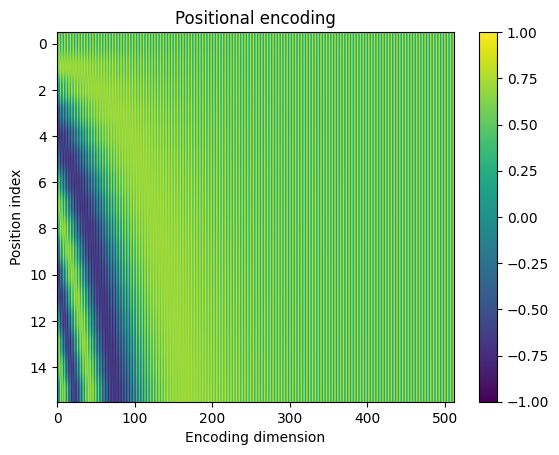

In [164]:
print('''
# ---------------------------------- 4/ Positional encoding  -----------------------------
''')

# Positional encoding
import math
position_encoding_lookup_table = torch.zeros(context_length, d_model)  # 位置信息编码初始化为0
print('位置信息 初始化为0：', position_encoding_lookup_table)
position = torch.arange(0, context_length, dtype=torch.float).unsqueeze(1) #一个形状为(n,)的一维张量转换为形状为(n, 1)的二维张量
print('position:', position)

div_term = torch.exp((-math.log(10000.0) * torch.arange(0, d_model, 2, dtype=torch.float) / d_model))
position_encoding_lookup_table[:, 0::2] = torch.sin(position * div_term) # 偶数位置的位置信息编码，使用正弦函数
print('position_encoding_lookup_table[:, 0::2]', position_encoding_lookup_table[:, 0::2])
position_encoding_lookup_table[:, 1::2] = torch.cos(position * div_term) # 奇数位置使用余弦函数
print('\nOur position_encoding_lookup_table as below:')
print(pd.DataFrame(position_encoding_lookup_table.detach().cpu().numpy()))
print('\n')
print('position_encoding_lookup_table形状：', position_encoding_lookup_table.shape)
position_encoding_lookup_table = position_encoding_lookup_table.unsqueeze(0).expand(batch_size, context_length, d_model)
print('\nOur position_encoding_lookup_table as below with batch size covered:', position_encoding_lookup_table.shape)
print('\n')

x = x + position_encoding_lookup_table
y = y + position_encoding_lookup_table

print('有了位置信息编码后的x形状:', x.shape, '\t\n', x)

# 可视化 visualization
import matplotlib.pyplot as plot
def visualize_pe(pe):
    plot.imshow(pe, aspect='auto')
    plot.title('Positional encoding')
    plot.xlabel('Encoding dimension')
    plot.ylabel('Position index')
    plot.colorbar()
    plot.show
visualize_pe(position_encoding_lookup_table[0].cpu().numpy())   # 图形解读：越接近1表示越相似
print('\n')


# ---------------------------------- 5/ Multi head attention -----------------------------

Prepare Q K V as below
	Q,K,V初始化后形状（weighted）均一致： torch.Size([4, 16, 512]) torch.Size([4, 16, 512]) torch.Size([4, 16, 512])
	Q、K、V把num_heads和context_length变换位置+切分多头之后的形状一样： torch.Size([4, 8, 16, 64]) torch.Size([4, 8, 16, 64]) torch.Size([4, 8, 16, 64])

Prepare attention as below:
	————> Attention1 Q @ K形状： torch.Size([4, 8, 16, 16])
          0         1          2          3          4         5         6   \
0   1.693208  6.429216  -6.396953   4.686251  11.838024  2.330540 -1.519378   
1   4.286064 -1.624539  -0.146614  -0.775374   5.537759  3.458097 -1.856459   
2   0.181444 -7.239130 -12.831924  -4.753388   5.305724  0.818653 -2.301800   
3   1.606031 -0.216383  -2.713365   2.108484   3.310697 -1.344965  0.832988   
4   0.745378  2.558960  -9.641855   6.637278   7.968750  0.036189  4.736765   
5  -0.799211  3.034062  -6.181821   6.760776   6.246933  3.186631  5.228459   
6   2.018361  0.

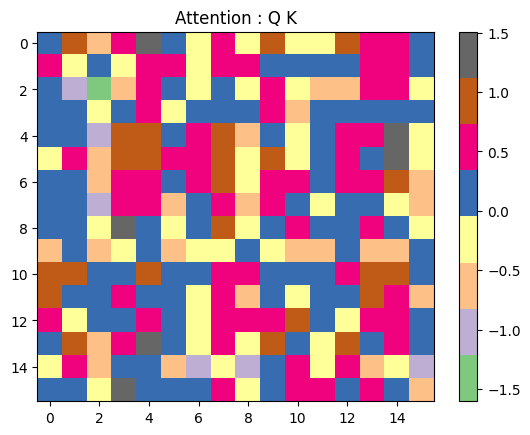

In [165]:
print('''
# ---------------------------------- 5/ Multi head attention -----------------------------
''')
import torch.nn as nn

# prepare Q,K,V weights square matrix(d_model)
Wq = nn.Linear(d_model, d_model)
Wk = nn.Linear(d_model, d_model)
Wv = nn.Linear(d_model, d_model)

Q = Wq(x)
K = Wk(x)
V = Wv(x)
print('Prepare Q K V as below')
print('\tQ,K,V初始化后形状（weighted）均一致：', Q.shape, K.shape, V.shape)

Q = Q.reshape(batch_size, context_length, num_heads, -1).permute(0,2,1,3)
K = K.reshape(batch_size, context_length, num_heads, -1).permute(0,2,1,3)
V = V.reshape(batch_size, context_length, num_heads, -1).permute(0,2,1,3)
print('\tQ、K、V把num_heads和context_length变换位置+切分多头之后的形状一样：', Q.shape, K.shape, V.shape)

 # Q @ K
attention = Q @ K.transpose(-2,-1)
print('\nPrepare attention as below:')
print('\t————> Attention1 Q @ K形状：', attention.shape)
print(pd.DataFrame(attention[0][0].detach().cpu().numpy()))

# scale
attention = attention / math.sqrt(d_model // num_heads)
print('\n\t————> Attention2 Q @ K/sqrt(d_model//num_heads)形状：', attention.shape)
print('留意与上一步数据大小对比（变小了）\n', pd.DataFrame(attention[0][0].detach().cpu().numpy()))

print('\n可视化看图 - 在Pycharm中无法查看；Jupyter中可看')
plot.imshow(attention[0][0].detach().cpu().numpy(),'Accent', aspect='auto')
plot.title('Attention : Q K')
plot.colorbar()


初始化mask是1 torch.Size([16, 16]) 
 tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
     

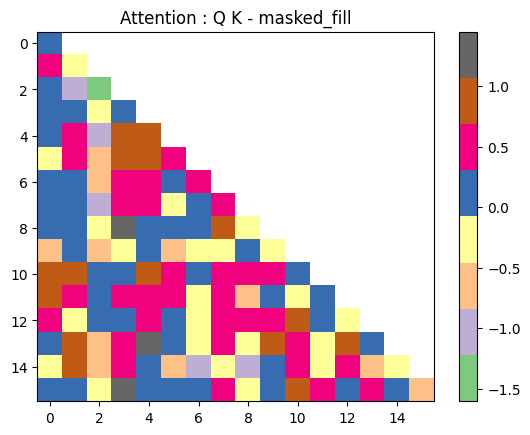

In [166]:
# mask
mask = torch.ones(attention.shape[-2:])
print('初始化mask是1', mask.shape, '\n', mask)
mask = torch.triu(mask, diagonal=1)
print('Create an upper triangular matrix with all values set to 1 and the rest set to 0', mask.shape, '\n',  mask)
mask = torch.triu(mask, diagonal=1).bool()
attention = attention.masked_fill(mask, float('-inf'))
print('\n\t————> Attention3 mask applied:\n', pd.DataFrame(attention[0][0].detach().cpu().numpy()))


print('\n可视化看图 - 在Pycharm中无法查看；Jupyter中可看')
plot.imshow(attention[0][0].detach().cpu().numpy(),'Accent', aspect='auto')
plot.title('Attention : Q K - masked_fill')
plot.colorbar()



In [167]:
# Probabilities - softmax
attention = torch.softmax(attention, dim=-1)  # 对最后一个维度dim=-1进行softmax
print('\n\t————> Attention4 概率化softmax\n', pd.DataFrame(attention[0][0].detach().cpu().numpy()))   # [0][0] 第一个批次第一个头

# @ V 回归最初形状
attention = attention @ V
print(f'\n\t————> Attention5 回归最初形状但还没合并{num_heads}个头\n', attention.shape, '\n', pd.DataFrame(attention[0][0].detach().cpu().numpy()))   # [0][0] 第一个批次第一个头

# concatenate heads
A = attention.transpose(1,2).reshape(batch_size, context_length,-1)  # -1是把d_model和num_heads做了合并列拼接
print('\t把多个头合并成X未分头时形状：', A.shape)
print(f'\n\t————> Attention6 多头合并后回归最初形状 - 第一个批次第一个字的{d_model}维度\n', pd.DataFrame(A[0][0].detach().cpu().numpy()))   # [0][0] 第一个批次第一个字的d_model维度坐标系

# output
Wo = nn.Linear(d_model, d_model)
output = Wo(A)

print('多头注意力的output形状和值如下：', output.shape)
print(f'某个token对应的{d_model}维度坐标系的位置:', A[0][2]) # 某个token对应的d_model坐标系的位置 ，第一个批次第三行所代表的token/文字




	————> Attention4 概率化softmax
           0         1         2         3         4         5         6   \
0   1.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1   0.676739  0.323261  0.000000  0.000000  0.000000  0.000000  0.000000   
2   0.628103  0.248423  0.123474  0.000000  0.000000  0.000000  0.000000   
3   0.290369  0.231216  0.169225  0.309191  0.000000  0.000000  0.000000   
4   0.141187  0.177112  0.038539  0.294881  0.348280  0.000000  0.000000   
5   0.102497  0.165504  0.052301  0.263706  0.247301  0.168691  0.000000   
6   0.140091  0.115539  0.067036  0.184593  0.194237  0.136217  0.162286   
7   0.117430  0.116536  0.037950  0.187955  0.180507  0.067595  0.114217   
8   0.096809  0.074247  0.055953  0.284359  0.092442  0.067136  0.097087   
9   0.073002  0.126060  0.062443  0.098123  0.154073  0.068779  0.085834   
10  0.141303  0.116286  0.070914  0.068703  0.147947  0.074704  0.061062   
11  0.176714  0.088387  0.074128  0.099790  0.091486  0.0

In [168]:
print('''
# ======================================= 如何打印参数 ======================================= 
''')

for name, value in Wo.named_parameters():  # Wo是自定义的变量 ，看参数时 ，把自定义的变量更换即可
    print(name, value.shape, value)



# ======================================= 如何打印参数 ======================================= 

weight torch.Size([512, 512]) Parameter containing:
tensor([[-0.0312, -0.0406, -0.0349,  ..., -0.0385, -0.0134, -0.0088],
        [-0.0103,  0.0267,  0.0267,  ...,  0.0052, -0.0362,  0.0220],
        [ 0.0139,  0.0044, -0.0290,  ...,  0.0200, -0.0352, -0.0383],
        ...,
        [ 0.0075,  0.0203, -0.0195,  ..., -0.0290, -0.0352, -0.0189],
        [-0.0011,  0.0162, -0.0083,  ...,  0.0187, -0.0340, -0.0134],
        [ 0.0161, -0.0384, -0.0029,  ...,  0.0256,  0.0319, -0.0089]],
       requires_grad=True)
bias torch.Size([512]) Parameter containing:
tensor([ 0.0387, -0.0401,  0.0048,  0.0278, -0.0280, -0.0023, -0.0422,  0.0210,
        -0.0142,  0.0205, -0.0196, -0.0166,  0.0135,  0.0194,  0.0031, -0.0085,
         0.0057, -0.0298,  0.0030, -0.0077, -0.0319, -0.0228,  0.0070, -0.0338,
        -0.0219, -0.0390, -0.0358,  0.0158,  0.0218, -0.0044, -0.0067, -0.0026,
        -0.0269,  0.0070,  0.0

In [169]:
# 此部分未跑通，待解决

# print('''
# # ======================================= # Visualize attention score using BervViz =======
# ''')
# # Visualize attention score using BervViz
# from bertviz import head_view, model_view
#
# attention_weights_first_head = [attention[i].unsqueeze(0) for i in range(batch_size)]
# # print(attention_weights_first_head[0].shape) # torch.size[1,4,16,16]
#
# # Create a list of lists  for the tokens(requreid by head_view)
# tokens_list = [[decode([idx])] for idx in x_batch[2].tolist()]
#
# head_view(attention_weights_first_head, tokens_list, prettify_tokens=False)

In [170]:
print('''
# ---------------------------------- 6/ Residual Connection & Layer Normalization --------
''')

# residual connection
output.shape, x.shape
output = output + x
print('\nBefore layer normalization, 为了观察方便，只看1列数据:\n', pd.DataFrame(output[0][2].detach().cpu().numpy()))

# Layer Normalization
layer_norm1 = nn.LayerNorm(d_model)
output2 = layer_norm1(output)
print('\nafter layer normalization, 为了观察方便，只看1列数据:\n', pd.DataFrame(output2[0][2].detach().cpu().numpy()))


# ---------------------------------- 6/ Residual Connection & Layer Normalization --------


Before layer normalization, 为了观察方便，只看1列数据:
             0
0    0.510251
1   -0.276211
2    1.032584
3   -1.386035
4   -0.480502
..        ...
507  0.076581
508 -0.491317
509  1.474043
510  0.365385
511  0.946050

[512 rows x 1 columns]

after layer normalization, 为了观察方便，只看1列数据:
             0
0    0.053794
1   -0.632588
2    0.509658
3   -1.601181
4   -0.810881
..        ...
507 -0.324690
508 -0.820320
509  0.894938
510 -0.072637
511  0.434135

[512 rows x 1 columns]


In [171]:
print('''
# ---------------------------------- 7/ Feed Forward -----------------------------------
''')

# Feed Forward
linear1 = nn.Linear(d_model, d_model *4)
output2 = linear1(output2)
print('\n升维提高精度, 为了观察方便，只看1列数据:\n', pd.DataFrame(output2[0][2].detach().cpu().numpy()))



# ---------------------------------- 7/ Feed Forward -----------------------------------


升维提高精度, 为了观察方便，只看1列数据:
              0
0     0.868889
1    -1.091959
2     0.435603
3    -0.304262
4    -0.161408
...        ...
2043  0.137481
2044 -0.307873
2045  0.138930
2046  0.483316
2047 -0.476923

[2048 rows x 1 columns]


In [172]:
output = nn.ReLU()(output2)
print('\nafter ReLU, 为了观察方便，只看1列数据:\n', pd.DataFrame(output2[0][2].detach().cpu().numpy()))



after ReLU, 为了观察方便，只看1列数据:
              0
0     0.868889
1    -1.091959
2     0.435603
3    -0.304262
4    -0.161408
...        ...
2043  0.137481
2044 -0.307873
2045  0.138930
2046  0.483316
2047 -0.476923

[2048 rows x 1 columns]


In [173]:
linear2 = nn.Linear(d_model * 4, d_model)
output2 = linear2(output2)
print('\n降维回归原有形状为后续计算做准备, 为了观察方便，只看1列数据:\n', pd.DataFrame(output2[0][2].detach().cpu().numpy()))


降维回归原有形状为后续计算做准备, 为了观察方便，只看1列数据:
             0
0    0.033314
1   -0.300233
2    0.253990
3   -0.037762
4    0.018474
..        ...
507 -0.387866
508  0.483930
509 -0.482819
510  0.013178
511 -0.422160

[512 rows x 1 columns]


In [174]:
for name, value in linear2.named_parameters():  # Wo是自定义的变量 ，看参数时 ，把自定义的变量更换即可
    print(name, value.shape, value)

weight torch.Size([512, 2048]) Parameter containing:
tensor([[-0.0124,  0.0049,  0.0135,  ..., -0.0191, -0.0140, -0.0101],
        [ 0.0134,  0.0057,  0.0159,  ...,  0.0217,  0.0157,  0.0146],
        [ 0.0059, -0.0084,  0.0181,  ..., -0.0172, -0.0195, -0.0146],
        ...,
        [-0.0079, -0.0158, -0.0156,  ...,  0.0166,  0.0058,  0.0193],
        [ 0.0052,  0.0130, -0.0185,  ..., -0.0132,  0.0027,  0.0211],
        [ 0.0118, -0.0184,  0.0088,  ...,  0.0192,  0.0164,  0.0198]],
       requires_grad=True)
bias torch.Size([512]) Parameter containing:
tensor([ 1.0334e-02,  4.3895e-03,  1.7447e-03, -1.8046e-02,  1.6384e-02,
         1.8172e-02, -6.8008e-03, -3.9660e-03, -1.0796e-02, -1.0120e-02,
         5.3265e-03,  1.1569e-02, -1.0668e-02,  1.9720e-02,  1.6561e-02,
         3.2630e-03,  1.8110e-02,  1.8637e-03, -9.1712e-03,  1.6934e-02,
         2.1175e-02, -1.7437e-02, -2.0915e-02,  7.6115e-03,  3.5111e-03,
         1.6590e-02, -9.8536e-04, -7.6630e-03, -4.5769e-03,  1.0464e-02,
   

In [175]:
print('''
# ---------------------------------- 8/ Residual Connection & Layer Normalization again -
''')

# Residual connection for the 2nd time
output = output2 + x
# Layer normalization for the 2nd time
layer_norm2 = nn.LayerNorm(d_model)
output = layer_norm2(output)
layer_norm2


# ---------------------------------- 8/ Residual Connection & Layer Normalization again -



LayerNorm((512,), eps=1e-05, elementwise_affine=True)

In [176]:
print('''
# ---------------------------------- 9/ Probalities ------------------------------------
''')

linear_vocab = nn.Linear(d_model, max_token)
output = linear_vocab(output)
output.shape


# ---------------------------------- 9/ Probalities ------------------------------------



torch.Size([4, 16, 5821])

In [177]:
output[0][2]

tensor([ 0.3455,  0.8450,  1.1280,  ..., -0.5795,  1.5358,  0.1752],
       grad_fn=<SelectBackward0>)

In [178]:
logits = torch.softmax(output, dim=-1)
sum(logits[0][0])
torch.argmax(logits[0][0])

tensor(4526)

In [179]:
logits.shape

torch.Size([4, 16, 5821])

In [180]:
decode([21])

'5'

In [181]:
cross_entropy = nn.CrossEntropyLoss()  # 交叉熵损失

In [182]:
print('''
# ---------------------------------- 10/ Back forward ----------------------------------
''')

# 目标文字和推理/预测出的文字对比以便用于计算 LOSS（结果形状相同，初次推理结果会有偏移，正常现象）
x_batch_decoded = []
for i in range(batch_size):
    x_batch_decoded.append(decode(x_batch[i].tolist()))

x_batch_decoded


# ---------------------------------- 10/ Back forward ----------------------------------



['这是饭店锅炉房的门，要不是这个门',
 '子说的话，其实马传香也说过，并且',
 '凡才舍得放开巧月的香唇。他早已知',
 '人面前会不会让自己难堪，如果俞雪']

In [183]:
predicted_indices = torch.argmax(logits, dim=-1)

logits_decoded = []
for i in range(batch_size):
    logits_decoded.append(decode(predicted_indices[i].tolist()))

logits_decoded


['蟀散颙宫衡狭甫孤戒道灿辑提蟀鹅缨',
 '嶙任轼氢道悍四葮蹋刃稣闹妺道沱募',
 '瓷桔寒吹梳寇斥丙孤刃邡彷毅桄桄镊',
 '蕊辑〖瑁辑瑁警设豆肃瞋道槁罩踪槁']

In [184]:
# 查看未进行反向更新权重参数，和反向更新的权重参数进行对比

for name, value in Wo.named_parameters():
    print(name, value.shape, value)

weight torch.Size([512, 512]) Parameter containing:
tensor([[-0.0312, -0.0406, -0.0349,  ..., -0.0385, -0.0134, -0.0088],
        [-0.0103,  0.0267,  0.0267,  ...,  0.0052, -0.0362,  0.0220],
        [ 0.0139,  0.0044, -0.0290,  ...,  0.0200, -0.0352, -0.0383],
        ...,
        [ 0.0075,  0.0203, -0.0195,  ..., -0.0290, -0.0352, -0.0189],
        [-0.0011,  0.0162, -0.0083,  ...,  0.0187, -0.0340, -0.0134],
        [ 0.0161, -0.0384, -0.0029,  ...,  0.0256,  0.0319, -0.0089]],
       requires_grad=True)
bias torch.Size([512]) Parameter containing:
tensor([ 0.0387, -0.0401,  0.0048,  0.0278, -0.0280, -0.0023, -0.0422,  0.0210,
        -0.0142,  0.0205, -0.0196, -0.0166,  0.0135,  0.0194,  0.0031, -0.0085,
         0.0057, -0.0298,  0.0030, -0.0077, -0.0319, -0.0228,  0.0070, -0.0338,
        -0.0219, -0.0390, -0.0358,  0.0158,  0.0218, -0.0044, -0.0067, -0.0026,
        -0.0269,  0.0070,  0.0275, -0.0044,  0.0101, -0.0316,  0.0368,  0.0367,
         0.0150,  0.0035,  0.0314, -0.0351

In [185]:
B, C, D = logits.shape
B, C, D

(4, 16, 5821)

In [186]:
logits_reshaped = logits.reshape(B * C, D)
y_batch_reshaped = y_batch.reshape(B * C)
logits_reshaped.shape , y_batch_reshaped.shape

(torch.Size([64, 5821]), torch.Size([64]))

In [187]:
import torch.nn.functional as F
loss = F.cross_entropy(input = logits_reshaped, target = logits_reshaped)

In [188]:
optimizer = torch.optim.AdamW(
    params = list(token_embedding_lookup_table.parameters()) + 
             list(Wo.parameters()) + 
             list(Wq.parameters()) +
             list(Wk.parameters()) + 
             list(Wv.parameters()) +
             list(linear1.parameters()) + 
             list(linear2.parameters()) +
             list(linear_vocab.parameters()) ,
    lr = 1e-4
)

loss.backward(retain_graph=True)
optimizer.step()

In [189]:
# 查看进行了反向更新权重参数，和前面未反向更新的权重参数进行对比

for name, value in Wo.named_parameters():
    print(name, value.shape, value)

weight torch.Size([512, 512]) Parameter containing:
tensor([[-0.0313, -0.0407, -0.0349,  ..., -0.0385, -0.0133, -0.0089],
        [-0.0103,  0.0267,  0.0266,  ...,  0.0052, -0.0361,  0.0219],
        [ 0.0139,  0.0044, -0.0290,  ...,  0.0200, -0.0353, -0.0382],
        ...,
        [ 0.0076,  0.0204, -0.0194,  ..., -0.0290, -0.0353, -0.0189],
        [-0.0011,  0.0162, -0.0084,  ...,  0.0188, -0.0339, -0.0134],
        [ 0.0161, -0.0385, -0.0029,  ...,  0.0257,  0.0319, -0.0089]],
       requires_grad=True)
bias torch.Size([512]) Parameter containing:
tensor([ 3.8753e-02, -4.0056e-02,  4.7817e-03,  2.7778e-02, -2.8007e-02,
        -2.3392e-03, -4.2257e-02,  2.1085e-02, -1.4218e-02,  2.0485e-02,
        -1.9574e-02, -1.6666e-02,  1.3489e-02,  1.9368e-02,  3.1900e-03,
        -8.5444e-03,  5.7208e-03, -2.9775e-02,  3.0118e-03, -7.6862e-03,
        -3.1972e-02, -2.2804e-02,  6.9854e-03, -3.3888e-02, -2.1941e-02,
        -3.9034e-02, -3.5753e-02,  1.5720e-02,  2.1850e-02, -4.4314e-03,
    

In [ ]:
作业：使用反向更新后的权重更新attention，进行图形对比，taik